# Polynomial Regression Project

## Retail Sales Analysis Using Quantity And Sales

**Company:** Walmart (Retail Industry)

## Problem Faced By Company
As already discussed the issue faced by Walmart and other similar retail companies. 
It is not always easy to understand how sales change when the quantity of products purchased changes.

## Solution For The Problem
To solve this issue, we use **Polynomial Regression** to study the **Relationship Between Quantity and Sales**.  

## Purpose 
- Study the effect of **Quantity** on **Sales**
- Check whether the relationship is **curved**
- And then evaluate the model using **MSE** and **R² Score**


## Step 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

## Step 2: Load the Dataset
Now we load the dataset of Supermarket Sales and some first few columns

In [2]:
df = pd.read_csv("Dataset/SuperMarket Analysis.csv")     ## load dataset 
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Step 3: Visualize the data
Now we use scatter plot which helps us to understand the  **Relationship Between Quantity and Sales** before training the model.

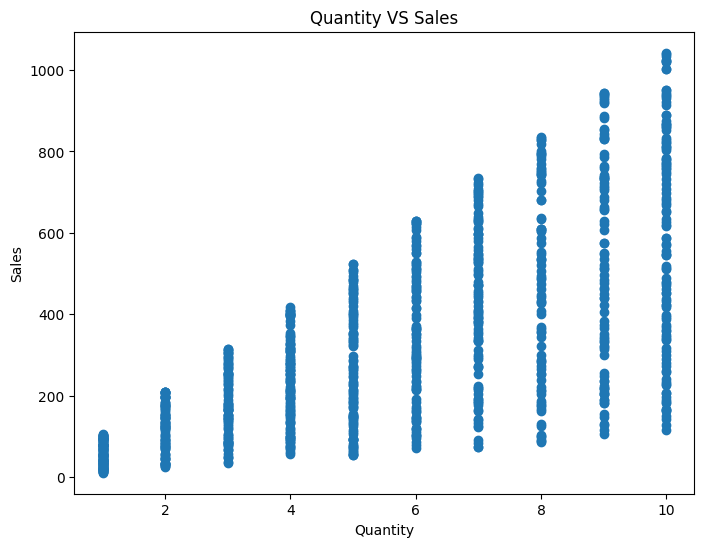

In [3]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df.Quantity, df.Sales)
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity VS Sales")
plt.show()

## Step 4: Selecting The Feature and Target
- **Feature (X):** Quantity
- **Target (y):** Sales

In [4]:
X = df[["Quantity"]]
y = df["Sales"]           # Select features and target 

## Step 5: Import Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)         # Split the data into training and testing data

In [6]:
X_test.shape  # Check Shape of Testing data

(200, 1)

## Step 7: Importing Polynomial Features


In [7]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

## Step 8: Create polynomial features
Now we change the input feature into polynomial form.  
We use **degree = 3**, so that the model will learn a curved pattern.

In [8]:
Scalar = StandardScaler()
X_train_Scalar = Scalar.fit_transform(X_train)
X_test_Scalar = Scalar.transform(X_test)

In [9]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
X_train[:5] # Checking the original training values

,Quantity
29,9
535,7
695,5
557,10
836,5


In [11]:
X_train_poly[:5] # Check transformed polynomial values

array([[   1.,    9.,   81.,  729.],
       [   1.,    7.,   49.,  343.],
       [   1.,    5.,   25.,  125.],
       [   1.,   10.,  100., 1000.],
       [   1.,    5.,   25.,  125.]])

## Step 6: Import  the Linear Regression Model
We use **LinearRegression()** after applying the polynomial transformation to fit the curve.

In [12]:
from sklearn.linear_model import LinearRegression         
model = LinearRegression()

## Step 7 : Train the model
The model learns the relationship between polynomial features and sales.

In [13]:
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 8: Make Predictions
Now we the help of the model we predicts the sales values for the testing data.

In [14]:
y_pred = model.predict(X_test_poly)
y_pred[:5]

array([348.18517804, 579.20031139, 406.54605143, 173.60461235,
       116.27615974])

In [15]:
y_test[:5] # Compare the Actual Values

521    523.9710
737    616.9800
740    408.7335
660    135.3555
411     45.9270
Name: Sales, dtype: float64

## Step 9: Importing The Evaluation Metrics
We use MSE and R² score to evaluate model performance

- **MSE (Mean Squared Error):** shows prediction error
- **R² Score:** shows how much model fits


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
mse = mean_squared_error(y_test, y_pred)
mse  # Calculating MSE

32080.337597653073

In [18]:
r2_score = r2_score(y_test, y_pred)
r2_score  # Calculating R² Score

0.5069039722138504

## Polynomial Regression Curve
This graph shows the actual data points and polynomial regression curve

In [19]:
x_range = pd.DataFrame(np.linspace(X["Quantity"].min(), X["Quantity"].max(), 100), columns=["Quantity"])
x_range_poly = poly.transform(x_range)
y_range_pred = model.predict(x_range_poly)

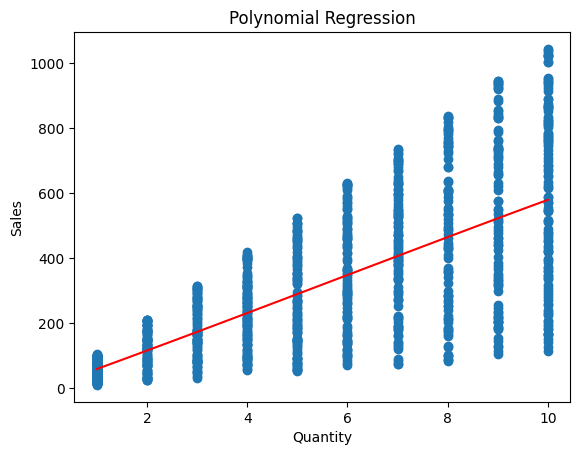

In [20]:
plt.scatter(X, y)
plt.plot(x_range, y_range_pred, color="red")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Polynomial Regression")
plt.show()

This graph shows that polynomial curve is very close to a straight line which indicates that the relationship between Quantity and Sales is not strongly non-linear.

## Conclusion
- In my Multiple Linear Regression model, the accuracy came around 90% because I used more than one useful column to predict Sales.
- But in Polynomial Regression when I changed the degree to make the line curved, the accuracy decreased. This means that Quantity and Sales do not have a very strong curved relation in this dataset.
- So just by changing the degree it doesn't mean that the model will become better. Sometimes the model learns from data, not increase the accuracy.

So, in my dataset the multiple linear model is giving best result than the polynomial regression.